,date,users,sessions,revenue
0,2024-01-01,202,310,1812.73
1,2024-01-02,448,516,2338.20
2,2024-01-03,370,448,4031.52
3,2024-01-04,206,240,1678.55
4,2024-01-05,171,241,1327.99
5,2024-01-06,288,415,3308.14
6,2024-01-07,120,194,1210.91
7,2024-01-08,202,285,1471.73
8,2024-01-09,221,291,1987.48
9,2024-01-10,314,354,2714.79


Кореляційна матриця:


,users,sessions,revenue
users,1.000000,0.962933,0.764334
sessions,0.962933,1.000000,0.738334
revenue,0.764334,0.738334,1.000000


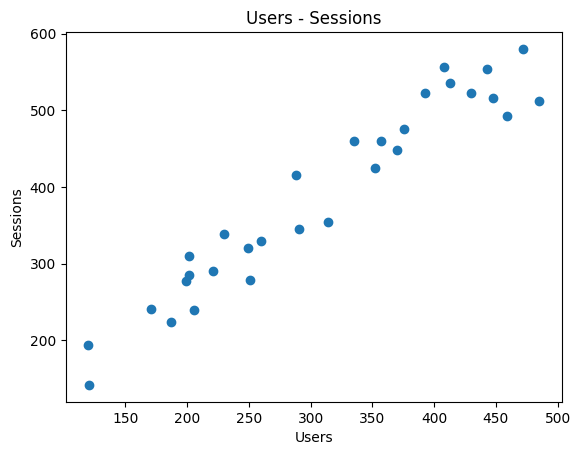

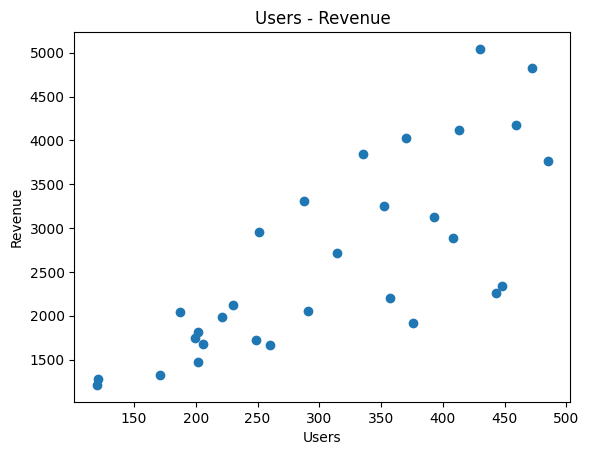

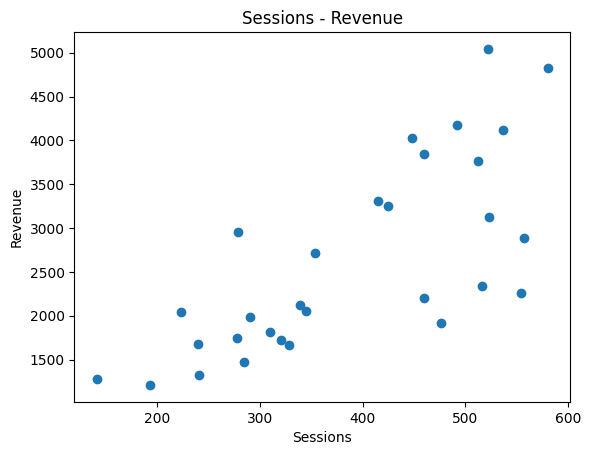

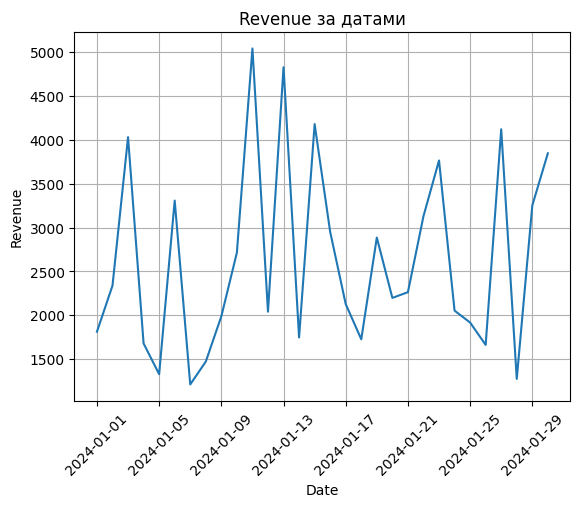

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

dates = pd.date_range(start="2024-01-01", periods=30)

users = np.random.randint(100, 500, size=30)
sessions = users + np.random.randint(20, 150, size=30)
revenue = users * np.random.uniform(5, 12, size=30)

df = pd.DataFrame({
    "date": dates,
    "users": users,
    "sessions": sessions,
    "revenue": revenue.round(2)
})

display(df)

correlation_matrix = df[["users", "sessions", "revenue"]].corr()

print("Кореляційна матриця:")
display(correlation_matrix)

plt.scatter(df["users"], df["sessions"])
plt.xlabel("Users")
plt.ylabel("Sessions")
plt.title("Users - Sessions")
plt.show()

plt.scatter(df["users"], df["revenue"])
plt.xlabel("Users")
plt.ylabel("Revenue")
plt.title("Users - Revenue")
plt.show()

plt.scatter(df["sessions"], df["revenue"])
plt.xlabel("Sessions")
plt.ylabel("Revenue")
plt.title("Sessions - Revenue")
plt.show()

plt.plot(df["date"], df["revenue"])
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.title("Revenue за датами")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

,group,converted
0,A,0
1,A,1
2,A,0
3,A,0
4,A,0
...,...,...
235,B,0
236,B,0
237,B,0
238,B,0


,conversion,count,ci_95
group,,,
A,0.116667,120,0.057438
B,0.150000,120,0.063888


Абсолютна різниця: 0.033333333333333326
Відносна зміна (%): 28.571428571428566


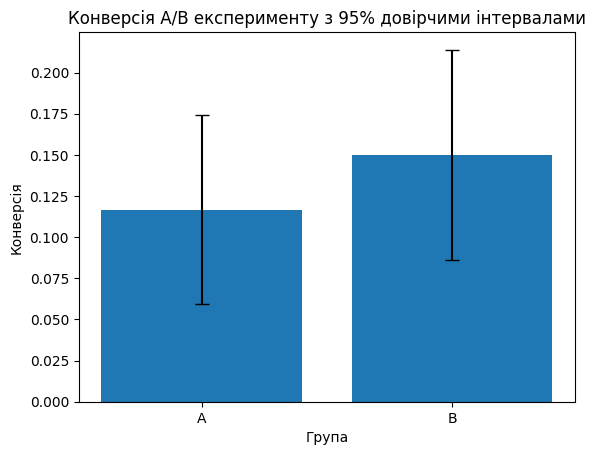

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

group_a = np.random.binomial(1, 0.12, size=120)
group_b = np.random.binomial(1, 0.16, size=120)

df_ab = pd.DataFrame({
    "group": ["A"] * 120 + ["B"] * 120,
    "converted": np.concatenate([group_a, group_b])
})

display(df_ab)

conversions = df_ab.groupby("group")["converted"].mean()
counts = df_ab.groupby("group")["converted"].count()

absolute_difference = conversions["B"] - conversions["A"]
relative_change = absolute_difference / conversions["A"] * 100

standard_error = np.sqrt(conversions * (1 - conversions) / counts)
confidence_interval = 1.96 * standard_error

result_ab = pd.DataFrame({
    "conversion": conversions,
    "count": counts,
    "ci_95": confidence_interval
})

display(result_ab)

print("Абсолютна різниця:", absolute_difference)
print("Відносна зміна (%):", relative_change)

plt.bar(result_ab.index, result_ab["conversion"], yerr=result_ab["ci_95"], capsize=5)
plt.xlabel("Група")
plt.ylabel("Конверсія")
plt.title("Конверсія A/B експерименту з 95% довірчими інтервалами")
plt.show()

Розмір підвибірки n = 10
Середнє вибіркових середніх: 1.9653427238910681
Стандартне відхилення вибіркових середніх: 0.6298489869410808


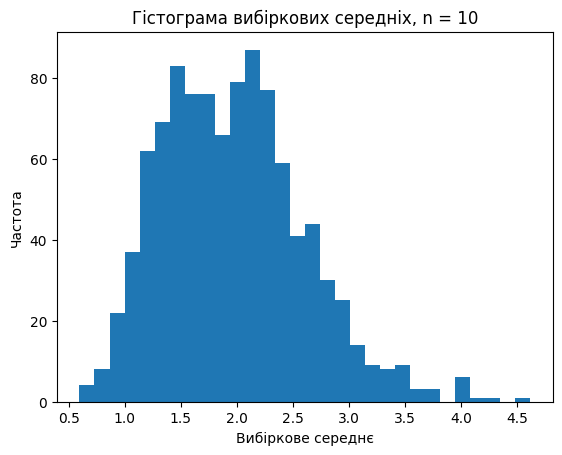

Розмір підвибірки n = 50
Середнє вибіркових середніх: 2.0063034305136123
Стандартне відхилення вибіркових середніх: 0.29176265575546373


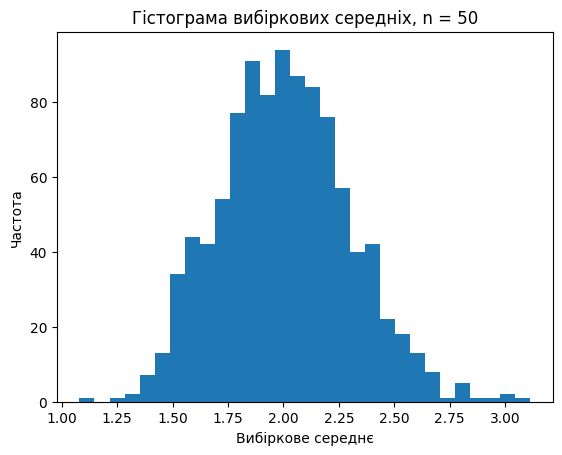

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

population = np.random.exponential(scale=2, size=50000)

sample_sizes = [10, 50]
number_of_samples = 1000

for n in sample_sizes:
    sample_means = []

    for i in range(number_of_samples):
        sample = np.random.choice(population, size=n)
        sample_means.append(np.mean(sample))

    sample_means = np.array(sample_means)

    print("Розмір підвибірки n =", n)
    print("Середнє вибіркових середніх:", sample_means.mean())
    print("Стандартне відхилення вибіркових середніх:", sample_means.std())

    plt.hist(sample_means, bins=30)
    plt.xlabel("Вибіркове середнє")
    plt.ylabel("Частота")
    plt.title(f"Гістограма вибіркових середніх, n = {n}")
    plt.show()


,date,sales,rolling_mean,rolling_std
0,2024-01-01,182,NaN,NaN
1,2024-01-02,133,NaN,NaN
2,2024-01-03,176,NaN,NaN
3,2024-01-04,100,NaN,NaN
4,2024-01-05,194,NaN,NaN
5,2024-01-06,161,NaN,NaN
6,2024-01-07,152,156.857143,32.199527
7,2024-01-08,114,147.142857,33.577912
8,2024-01-09,198,156.428571,37.744126
9,2024-01-10,180,157.000000,38.118237


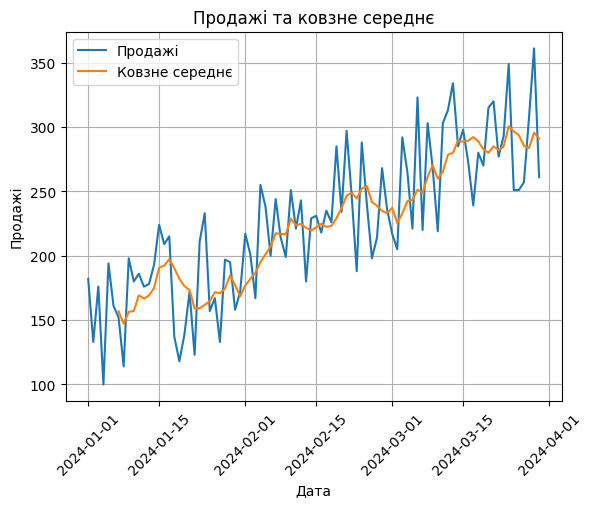

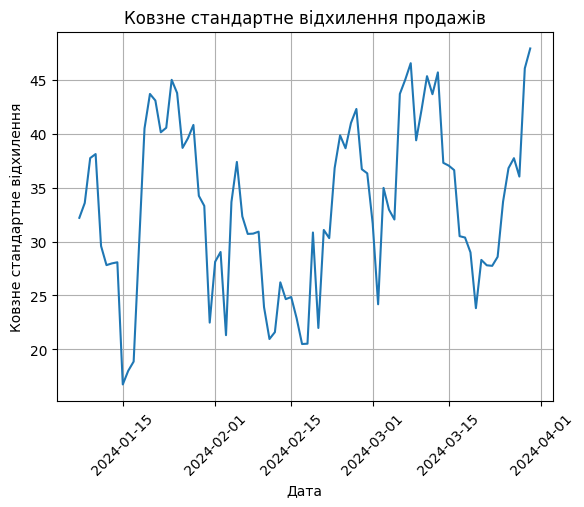

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

dates = pd.date_range(start="2024-01-01", periods=90)

sales = np.random.randint(80, 200, size=90) + np.arange(90) * 2

df_sales = pd.DataFrame({
    "date": dates,
    "sales": sales
})

window = 7

df_sales["rolling_mean"] = df_sales["sales"].rolling(window=window).mean()
df_sales["rolling_std"] = df_sales["sales"].rolling(window=window).std()

display(df_sales.head(15))

plt.plot(df_sales["date"], df_sales["sales"], label="Продажі")
plt.plot(df_sales["date"], df_sales["rolling_mean"], label="Ковзне середнє")

plt.xlabel("Дата")
plt.ylabel("Продажі")
plt.title("Продажі та ковзне середнє")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

plt.plot(df_sales["date"], df_sales["rolling_std"])

plt.xlabel("Дата")
plt.ylabel("Ковзне стандартне відхилення")
plt.title("Ковзне стандартне відхилення продажів")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()